In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [2]:
df = pd.read_csv("/content/payroll_ml_dataset_5000.csv")
df.head()

,Employee_ID,Month,Department,Experience_Years,Base_Salary_INR,Attendance_Percent,Working_Days,Leave_Days,OT_Hours,Bonus_INR,Deductions_INR,Previous_Payroll_INR,Payroll_Cost_INR,Absenteeism_Risk,Anomaly
0,1,Jun,HR,12,39329,81,20,4,34,771,1497,25000,47496,High,1
1,2,Jan,IT,6,19228,82,23,5,26,572,985,47496,24700,High,1
2,3,Sep,Operations,1,45094,98,20,1,14,5166,2569,24700,51584,Low,0
3,4,Jan,IT,12,19624,87,20,3,35,7032,545,51584,34654,Medium,0
4,5,Jul,HR,3,36707,89,24,3,11,844,2382,34654,38288,Medium,0


In [3]:
month_encoder = LabelEncoder()
department_encoder = LabelEncoder()

df["Month"] = month_encoder.fit_transform(df["Month"])
df["Department"] = department_encoder.fit_transform(df["Department"])

In [4]:
X = df.drop(columns=[
    "Employee_ID",
    "Payroll_Cost_INR",
    "Absenteeism_Risk",
    "Anomaly"
])

y = df["Payroll_Cost_INR"]

In [5]:
print(X.columns.tolist())
print(X.select_dtypes(include=["object"]).columns)

['Month', 'Department', 'Experience_Years', 'Base_Salary_INR', 'Attendance_Percent', 'Working_Days', 'Leave_Days', 'OT_Hours', 'Bonus_INR', 'Deductions_INR', 'Previous_Payroll_INR']
Index([], dtype='object')


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
print(X_train.select_dtypes(include=["object"]).columns)

Index([], dtype='object')


In [8]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [9]:
y_pred = model.predict(X_test)

In [10]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 713.86849
RMSE: 884.6106568198803
R² Score: 0.9915138808169564


In [11]:
comparison = pd.DataFrame({
    "Actual Payroll": y_test.values,
    "Predicted Payroll": y_pred
})

comparison.head(10)

,Actual Payroll,Predicted Payroll
0,36058,37342.76
1,41839,41296.47
2,37487,37434.39
3,32671,33247.17
4,39715,38550.53
5,40789,41384.69
6,48252,49441.86
7,37114,38258.63
8,34409,35173.54
9,44929,44865.25


In [12]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                 Feature  Importance
3        Base_Salary_INR    0.855348
7               OT_Hours    0.084914
8              Bonus_INR    0.049478
9         Deductions_INR    0.005375
10  Previous_Payroll_INR    0.001099
2       Experience_Years    0.000834
0                  Month    0.000782
4     Attendance_Percent    0.000733
5           Working_Days    0.000610
1             Department    0.000498
6             Leave_Days    0.000329


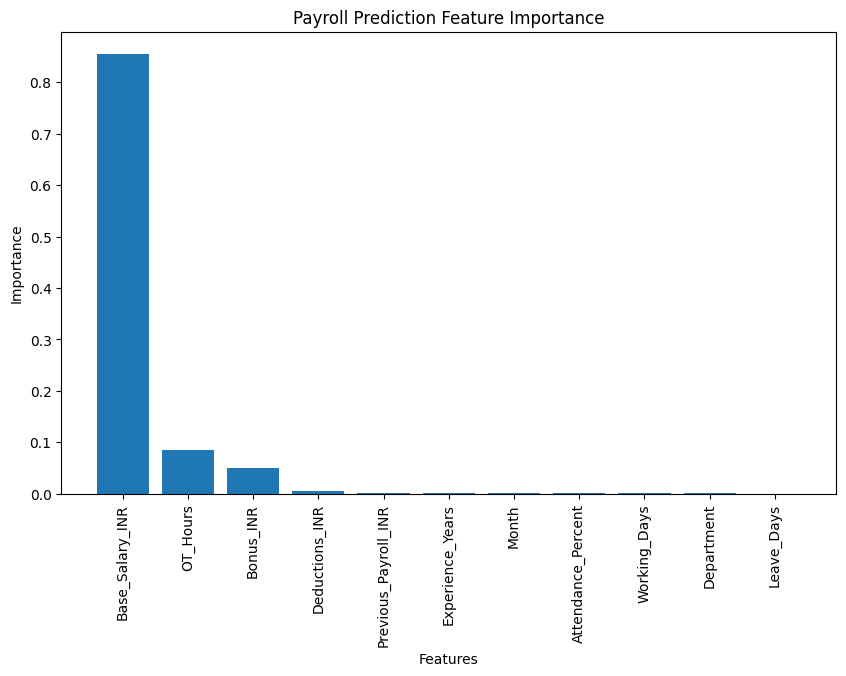

In [13]:
plt.figure(figsize=(10,6))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=90)

plt.title("Payroll Prediction Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

In [14]:
joblib.dump(model, "payroll_forecast_model.pkl")

['payroll_forecast_model.pkl']

In [15]:
import os

print(os.listdir())

['.config', 'payroll_forecast_model.pkl', 'payroll_ml_dataset_5000.csv', 'sample_data']


In [16]:
from google.colab import files

files.download("payroll_forecast_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>